# Scaling 

In [6]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import ( 
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer 
) 
  
# Sample dataset 
df = pd.DataFrame({ 
    "age": [25, 32, 47, 51, 62, 23, 90], 
    "income": [40000, 52000, 61000, 300000, 82000, 39000, 75000] 
}) 


df

,age,income
0,25,40000
1,32,52000
2,47,61000
3,51,300000
4,62,82000
5,23,39000
6,90,75000


In [7]:
# ‐‐‐‐ 1. Standardization (Z‐score) ‐‐‐‐ 
scaler = StandardScaler() 
df["age_std"] = scaler.fit_transform(df[["age"]]) 

In [8]:
df

,age,income,age_std
0,25,40000,-1.008451
1,32,52000,-0.689651
2,47,61000,-0.006506
3,51,300000,0.175666
4,62,82000,0.676638
5,23,39000,-1.099537
6,90,75000,1.951841


In [9]:
scaler = StandardScaler() 
df["income_std"] = scaler.fit_transform(df[["income"]]) 
df

,age,income,age_std,income_std
0,25,40000,-1.008451,-0.613245
1,32,52000,-0.689651,-0.473644
2,47,61000,-0.006506,-0.368944
3,51,300000,0.175666,2.411430
4,62,82000,0.676638,-0.124643
5,23,39000,-1.099537,-0.624878
6,90,75000,1.951841,-0.206077


In [10]:
# ‐‐‐‐ 2. Min‐Max Normalization ‐‐‐‐ 
minmax = MinMaxScaler(feature_range=(0, 1)) 
df["age_minmax"] = minmax.fit_transform(df[["age"]]) 
df["income_minmax"] = minmax.fit_transform(df[["income"]]) 
  
# ‐‐‐‐ 3. Robust Scaling (handles outliers, e.g. income) ‐‐‐‐ 
robust = RobustScaler() 
df["age_robust"] = robust.fit_transform(df[["age"]]) 
df["income_robust"] = robust.fit_transform(df[["income"]])


df

,age,income,age_std,income_std,age_minmax,income_minmax,age_robust,income_robust
0,25,40000,-1.008451,-0.613245,0.029851,0.003831,-0.785714,-0.646154
1,32,52000,-0.689651,-0.473644,0.134328,0.049808,-0.535714,-0.276923
2,47,61000,-0.006506,-0.368944,0.358209,0.084291,0.000000,0.000000
3,51,300000,0.175666,2.411430,0.417910,1.000000,0.142857,7.353846
4,62,82000,0.676638,-0.124643,0.582090,0.164751,0.535714,0.646154
5,23,39000,-1.099537,-0.624878,0.000000,0.000000,-0.857143,-0.676923
6,90,75000,1.951841,-0.206077,1.000000,0.137931,1.535714,0.430769


# Encoding 

In [11]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder 
  
df = pd.DataFrame({ 
    "city": ["Delhi", "Mumbai", "Delhi", "Chennai", "Mumbai"], 
    "education": ["Bachelors", "Masters", "PhD", "Bachelors", "Masters"], 
    "target": [1, 0, 1, 0, 1] 
}) 
df

,city,education,target
0,Delhi,Bachelors,1
1,Mumbai,Masters,0
2,Delhi,PhD,1
3,Chennai,Bachelors,0
4,Mumbai,Masters,1


In [12]:
# ‐‐‐‐ A. Label Encoding ‐‐‐‐ 
le = LabelEncoder() 
df["city_label"] = le.fit_transform(df["city"]) 
df


,city,education,target,city_label
0,Delhi,Bachelors,1,1
1,Mumbai,Masters,0,2
2,Delhi,PhD,1,1
3,Chennai,Bachelors,0,0
4,Mumbai,Masters,1,2


In [14]:
df["education_label"] = le.fit_transform(df["education"]) 
df

,city,education,target,city_label,city_label1,education_label
0,Delhi,Bachelors,1,1,1,0
1,Mumbai,Masters,0,2,2,1
2,Delhi,PhD,1,1,1,2
3,Chennai,Bachelors,0,0,0,0
4,Mumbai,Masters,1,2,2,1


In [17]:
df = pd.DataFrame({ 
    "city": ["Delhi", "Mumbai", "Delhi", "Chennai", "Mumbai"], 
    "education": ["Bachelors", "Masters", "PhD", "Bachelors", "Masters"], 
    "target": [1, 0, 1, 0, 1] 
}) 
df

,city,education,target
0,Delhi,Bachelors,1
1,Mumbai,Masters,0
2,Delhi,PhD,1
3,Chennai,Bachelors,0
4,Mumbai,Masters,1


In [16]:
# ‐‐‐‐ C. Ordinal Encoding (explicit order) ‐‐‐‐ 
edu_order = [["Bachelors", "Masters", "PhD"]] 
ord_enc = OrdinalEncoder(categories=edu_order) 
df["education_ordinal"] = ord_enc.fit_transform(df[["education"]]) 
df

,city,education,target,education_ordinal
0,Delhi,Bachelors,1,0.0
1,Mumbai,Masters,0,1.0
2,Delhi,PhD,1,2.0
3,Chennai,Bachelors,0,0.0
4,Mumbai,Masters,1,1.0


In [18]:
edu_order = [["Bachelors","PhD", "Masters"]] 
ord_enc = OrdinalEncoder(categories=edu_order) 
df["education_ordinal"] = ord_enc.fit_transform(df[["education"]]) 
df

,city,education,target,education_ordinal
0,Delhi,Bachelors,1,0.0
1,Mumbai,Masters,0,2.0
2,Delhi,PhD,1,1.0
3,Chennai,Bachelors,0,0.0
4,Mumbai,Masters,1,2.0


In [23]:
df = pd.DataFrame({ 
    "city": ["Delhi", "Mumbai", "Delhi", "Chennai", "Mumbai"], 
    "education": ["Bachelors", "Masters", "PhD", "Bachelors", "Masters"], 
    "target": [1, 0, 1, 0, 1] 
}) 
df

,city,education,target
0,Delhi,Bachelors,1
1,Mumbai,Masters,0
2,Delhi,PhD,1
3,Chennai,Bachelors,0
4,Mumbai,Masters,1


In [25]:
# ‐‐‐‐ B. One‐Hot Encoding (pandas) ‐‐‐‐ 
df_ohe = pd.get_dummies(df, columns=["city"], prefix="city") 
df_ohe

,education,target,city_Chennai,city_Delhi,city_Mumbai
0,Bachelors,1,False,True,False
1,Masters,0,False,False,True
2,PhD,1,False,True,False
3,Bachelors,0,True,False,False
4,Masters,1,False,False,True


In [26]:
df

,city,education,target
0,Delhi,Bachelors,1
1,Mumbai,Masters,0
2,Delhi,PhD,1
3,Chennai,Bachelors,0
4,Mumbai,Masters,1


In [29]:
# ‐‐‐‐ B (alt). One‐Hot Encoding (sklearn, fits into pipelines) ‐‐‐‐ 
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore") 
city_ohe = ohe.fit_transform(df[["city"]])

In [30]:
city_ohe

array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

# Skewness

In [52]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import ( 
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer 
) 
  
# Sample dataset 
df = pd.DataFrame({ 
    "age": [25, 32, 47, 51, 62, 23, 90], 
    "income": [40000, 52000, 61000, 300000, 82000, 39000, 75000] 
}) 


df

,age,income
0,25,40000
1,32,52000
2,47,61000
3,51,300000
4,62,82000
5,23,39000
6,90,75000


In [53]:
from scipy.stats import skew 
print("Skewness for income:", skew(df["income"]))
print("Skewness for age :", skew(df["age"]))

Skewness for income: 1.911525038845622
Skewness for age : 0.7240303991805316


In [55]:
# # Visual check 
# import matplotlib.pyplot as plt 
# import seaborn as sns 
# df["income"].hist(bins=10) 
# plt.title("Income Distribution")
# plt.show()

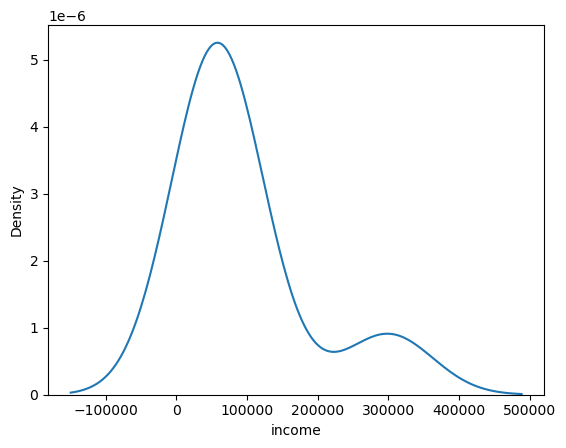

In [56]:
sns.kdeplot(data = df["income"])
plt.show()

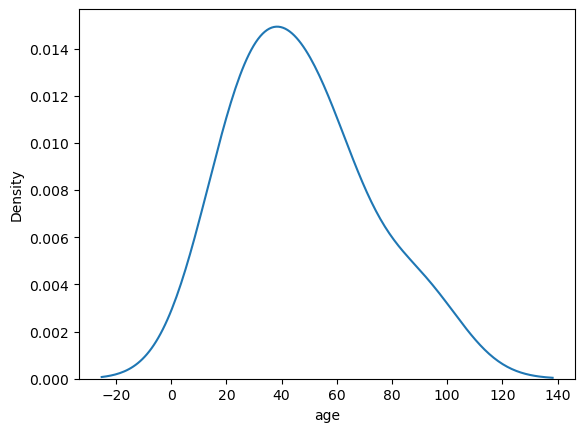

In [57]:
sns.kdeplot(data = df["age"])
plt.show()

In [58]:
import pandas as pd 
from scipy.stats import skew      
df = pd.DataFrame({"income": [22000, 25000, 27000, 30000, 32000, 
35000, 40000, 250000, 300000, 500000]}) 
print("Skewness:", skew(df["income"]))   
# scipy method 
print("Pandas skew:", df["income"].skew())       
# pandas built‐in  

Skewness: 1.344826806817432
Pandas skew: 1.5947684129978785


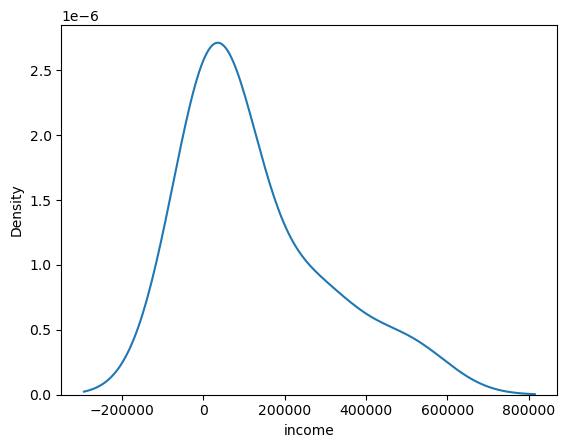

In [59]:
sns.kdeplot(data = df["income"])
plt.show()

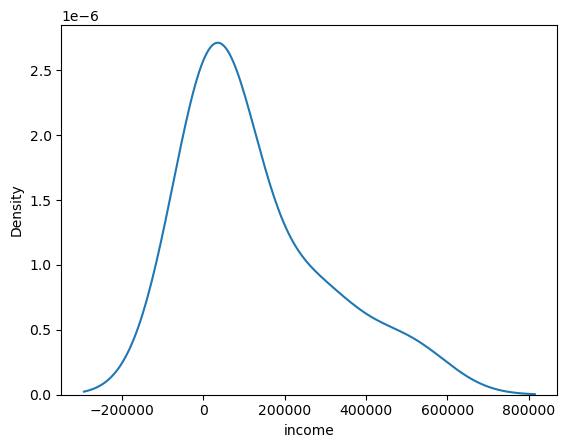

In [4]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats 
from sklearn.preprocessing import PowerTransformer 
df = pd.DataFrame({"income": [22000, 25000, 27000, 30000, 32000, 
35000, 40000, 250000, 300000, 500000]}) 
sns.kdeplot(data = df["income"])
plt.show()


In [5]:
df

,income
0,22000
1,25000
2,27000
3,30000
4,32000
5,35000
6,40000
7,250000
8,300000
9,500000


In [65]:
# ‐‐‐‐ A. Log Transform ‐‐‐‐ 
df["income_log"] = np.log1p(df["income"])        # log(1 + x), safe for zeros
df

,income,income_log
0,22000,9.998843
1,25000,10.126671
2,27000,10.203629
3,30000,10.308986
4,32000,10.373522
5,35000,10.463132
6,40000,10.596660
7,250000,12.429220
8,300000,12.611541
9,500000,13.122365


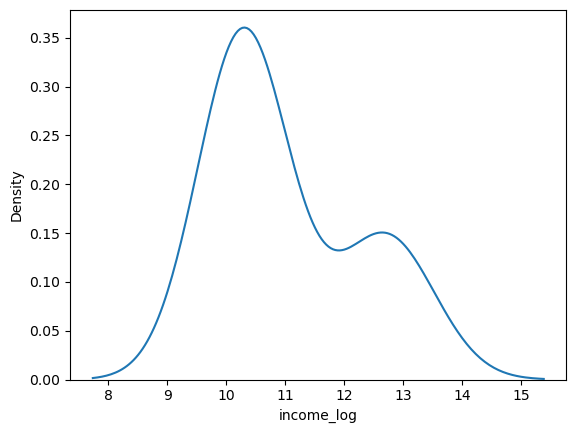

In [66]:
sns.kdeplot(data = df["income_log"])
plt.show()

In [68]:
print("Initial Skewness:", skew(df["income"])) 
print("Final Skewness after transformation :", skew(df["income_log"])) 

Initial Skewness: 1.344826806817432
Final Skewness after transformation : 0.877070343585971


In [71]:
# ‐‐‐ B. Square Root Transform ‐‐‐‐ 
df["income_sqrt"] = np.sqrt(df["income"]) 
print("Initial Skewness:", skew(df["income"])) 
print("Final Skewness after transformation :", skew(df["income_sqrt"]))
df

Initial Skewness: 1.344826806817432
Final Skewness after transformation : 1.0662610203502956


,income,income_log,income_sqrt
0,22000,9.998843,148.323970
1,25000,10.126671,158.113883
2,27000,10.203629,164.316767
3,30000,10.308986,173.205081
4,32000,10.373522,178.885438
5,35000,10.463132,187.082869
6,40000,10.596660,200.000000
7,250000,12.429220,500.000000
8,300000,12.611541,547.722558
9,500000,13.122365,707.106781


In [6]:
# ‐‐‐‐ C. Box‐Cox (requires strictly positive values) ‐‐‐‐ 

df["income_boxcox"], best_lambda = stats.boxcox(df["income"]) 
print("Optimal Box‐Cox lambda:", best_lambda) 


Optimal Box‐Cox lambda: -0.8187833814352683


In [7]:
df

,income,income_boxcox
0,22000,1.220984
1,25000,1.221018
2,27000,1.221037
3,30000,1.221061
4,32000,1.221074
5,35000,1.221092
6,40000,1.221116
7,250000,1.221278
8,300000,1.221284
9,500000,1.221298


# Filter Method: Variance Threshold & Correlation

In [8]:
import pandas as pd 
import numpy as np 
from sklearn.feature_selection import VarianceThreshold 


df = pd.DataFrame({ 
    "f1": [1, 1, 1, 1, 1],          # zero variance ‐> useless 
    "f2": [1, 2, 3, 4, 5], 
    "f3": [10, 9, 8, 7, 6], 
    "target": [0, 1, 0, 1, 1] 
}) 

df

,f1,f2,f3,target
0,1,1,10,0
1,1,2,9,1
2,1,3,8,0
3,1,4,7,1
4,1,5,6,1


In [9]:
# ‐‐‐‐ Variance Threshold ‐‐‐‐ 
selector = VarianceThreshold(threshold=0.0) 
selector.fit(df[["f1", "f2", "f3"]]) 
kept_cols = df[["f1", "f2", "f3"]].columns[selector.get_support()] 
print("Kept after variance threshold:", list(kept_cols)) 

Kept after variance threshold: ['f2', 'f3']


In [10]:
# ‐‐‐‐ Correlation with target ‐‐‐‐ 
corr = df.corr()["target"].drop("target").abs().sort_values(ascending=False) 
print("Correlation with target:\n", corr) 

Correlation with target:
 f2    0.57735
f3    0.57735
f1        NaN
Name: target, dtype: float64


In [11]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif 
from sklearn.datasets import load_iris 
  
X, y = load_iris(return_X_y=True) 
  
# ‐‐‐‐ Chi‐Square (requires non‐negative features) ‐‐‐‐ 
chi_selector = SelectKBest(score_func=chi2, k=2) 
X_chi = chi_selector.fit_transform(X, y) 
print("Chi2 scores:", chi_selector.scores_) 
  
# ‐‐‐‐ ANOVA F‐test (numeric features, categorical target) ‐‐‐‐ 
f_selector = SelectKBest(score_func=f_classif, k=2) 
X_f = f_selector.fit_transform(X, y) 
print("ANOVA F‐scores:", f_selector.scores_) 

Chi2 scores: [ 10.81782088   3.7107283  116.31261309  67.0483602 ]
ANOVA F‐scores: [ 119.26450218   49.16004009 1180.16118225  960.0071468 ]


In [12]:
X_chi

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,

In [13]:
X_f

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,